# 🧠 GNN Training & Evaluation — GraphSAGE & GAT

**Goal:** Train Graph Neural Networks that exploit the **graph structure** of Bitcoin transactions to detect fraud, and compare against the feature-only baselines from Notebook 03.

**Key insight:** A transaction surrounded by illicit neighbors is far more likely to be illicit — GNNs capture this through **message passing**.

---

### Models

| Model | Key Mechanism | Architecture |
|-------|--------------|-------------|
| **GraphSAGE** | Mean aggregation of neighbor features | 2× SAGEConv + BatchNorm + Dropout → Linear |
| **GAT** | Learned attention weights on neighbors | 2× GATConv (8 heads → 1 head) + Dropout |

### Notebook Structure

| # | Section | Purpose |
|---|---------|---------|
| 1 | Imports & Config | Libraries + hyperparameters |
| 2 | Load Processed Data | Load saved graph from Notebook 02 |
| 3 | Define GraphSAGE Model | 2-layer SAGEConv with BatchNorm |
| 4 | Define GAT Model | 2-layer GATConv with multi-head attention |
| 5 | Training & Evaluation Utilities | Train loop, validation, early stopping |
| 6 | Train GraphSAGE | Full training run |
| 7 | GraphSAGE — Training Curves | Loss + F1 over epochs |
| 8 | Evaluate GraphSAGE | Test set metrics + plots |
| 9 | Train GAT | Full training run |
| 10 | GAT — Training Curves | Loss + F1 over epochs |
| 11 | Evaluate GAT | Test set metrics + plots |
| 12 | Full Model Comparison | Baselines + GNNs side by side |
| 13 | PR Curve Overlay (All Models) | Visual comparison |
| 14 | GNNExplainer | Explain sample illicit predictions |
| 15 | Key Takeaways | Summary + conclusions |

---
## 1. Imports & Config

**Hyperparameters** (following the GNN fraud detection literature):

| Parameter | Value | Why |
|-----------|-------|-----|
| `lr` | 0.001 | Standard for GNN training |
| `epochs` | 200 | Max training iterations |
| `patience` | 20 | Early stopping if val F1 stalls |
| `hidden_channels` | 64 | Sufficient for 166→2 mapping |
| `dropout` | 0.5 | Prevent overfitting |
| `weight_decay` | 5e-4 | L2 regularization |

In [1]:
import os
import json
import warnings
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv, GATConv, BatchNorm
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.metrics import (
    f1_score, precision_recall_curve, average_precision_score,
    confusion_matrix, classification_report, accuracy_score
)

# Config
warnings.filterwarnings("ignore")
sns.set_theme(style="darkgrid", context="notebook", font_scale=1.1)
PALETTE = {"Illicit": "#e74c3c", "Licit": "#2ecc71", "Unknown": "#95a5a6"}

PROCESSED_DIR = "../data/processed"
RESULTS_DIR = "../results"
PLOT_DIR = "../results/plots/gnn"
os.makedirs(PLOT_DIR, exist_ok=True)

# Hyperparameters
config = {
    "lr": 0.001,
    "epochs": 200,
    "patience": 20,
    "hidden_channels": 64,
    "dropout": 0.5,
    "weight_decay": 5e-4,
}

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Imports loaded — Device: {device}")
print(f"   Config: {config}")

/Users/piyushmaji/Desktop/Project/GNN-FraudNet/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ Imports loaded — Device: cpu
   Config: {'lr': 0.001, 'epochs': 200, 'patience': 20, 'hidden_channels': 64, 'dropout': 0.5, 'weight_decay': 0.0005}


---
## 2. Load Processed Data

**What:** Load the PyG `Data` object created in Notebook 02 and move to device.

In [2]:
data = torch.load(os.path.join(PROCESSED_DIR, "elliptic_graph.pt"), weights_only=False)
data = data.to(device)

print(f"Loaded graph:")
print(f"  {data}")
print(f"  Device: {data.x.device}")

# Compute class weights for loss function
train_labels = data.y[data.train_mask]
n_licit = (train_labels == 0).sum().item()
n_illicit = (train_labels == 1).sum().item()
w_licit = (n_licit + n_illicit) / (2.0 * n_licit)
w_illicit = (n_licit + n_illicit) / (2.0 * n_illicit)
class_weights = torch.tensor([w_licit, w_illicit], dtype=torch.float).to(device)
print(f"  Class weights: {class_weights.cpu().numpy()}")

Loaded graph:
  Data(x=[203769, 166], edge_index=[2, 234355], y=[203769], train_mask=[203769], val_mask=[203769], test_mask=[203769])
  Device: cpu
  Class weights: [0.5543763 5.0975914]


---
## 3. Define GraphSAGE Model

**Architecture:**
```
Input (166 features)
  → SAGEConv(166, 64) → BatchNorm → ReLU → Dropout(0.5)
  → SAGEConv(64, 64) → BatchNorm → ReLU → Dropout(0.5)
  → Linear(64, 2) → output logits
```

**How SAGEConv works:**
1. **Sample** neighbors of each node
2. **Aggregate** neighbor features (mean pooling)
3. **Concatenate** aggregated features with node's own features
4. **Transform** through a learned weight matrix

This allows each node to "see" its local neighborhood and make predictions informed by surrounding transactions.

In [3]:
class GraphSAGEModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers=2, dropout=0.5):
        super().__init__()
        self.dropout = dropout

        self.convs = nn.ModuleList()
        self.bns = nn.ModuleList()

        # First layer: in_channels → hidden_channels
        self.convs.append(SAGEConv(in_channels, hidden_channels))
        self.bns.append(BatchNorm(hidden_channels))

        # Hidden layers
        for _ in range(num_layers - 1):
            self.convs.append(SAGEConv(hidden_channels, hidden_channels))
            self.bns.append(BatchNorm(hidden_channels))

        # Final classifier
        self.classifier = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        for conv, bn in zip(self.convs, self.bns):
            x = conv(x, edge_index)
            x = bn(x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
        return self.classifier(x)

    def reset_parameters(self):
        for conv in self.convs:
            conv.reset_parameters()
        for bn in self.bns:
            bn.reset_parameters()
        self.classifier.reset_parameters()

# Test instantiation
sage_model = GraphSAGEModel(
    in_channels=data.x.size(1),
    hidden_channels=config["hidden_channels"],
    out_channels=2,
    dropout=config["dropout"]
).to(device)

print(sage_model)
n_params = sum(p.numel() for p in sage_model.parameters())
print(f"\nTotal parameters: {n_params:,}")

GraphSAGEModel(
  (convs): ModuleList(
    (0): SAGEConv(166, 64, aggr=mean)
    (1): SAGEConv(64, 64, aggr=mean)
  )
  (bns): ModuleList(
    (0-1): 2 x BatchNorm(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (classifier): Linear(in_features=64, out_features=2, bias=True)
)

Total parameters: 29,954


---
## 4. Define GAT Model

**Architecture:**
```
Input (166 features)
  → GATConv(166, 8, heads=8) → ELU → Dropout(0.5)      [output: 64 = 8×8]
  → GATConv(64, 2, heads=1, concat=False) → output logits
```

**How GATConv works:**
1. Compute **attention coefficients** for each edge: how important is neighbor j to node i?
2. **Weight** neighbor features by attention scores
3. **Aggregate** weighted features (multi-head: run in parallel, concatenate/average)
4. This lets the model learn which neighbors are most informative — crucial when some neighbors are noise

**Why 8 heads?** Multiple attention heads stabilize training and capture diverse relationship patterns.

In [4]:
class GATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, heads=8, dropout=0.5):
        super().__init__()
        self.dropout = dropout

        # Layer 1: multi-head attention
        # Output dim = hidden_channels (per head) × heads
        self.conv1 = GATConv(in_channels, hidden_channels, heads=heads, dropout=dropout)

        # Layer 2: single head, average (concat=False)
        self.conv2 = GATConv(hidden_channels * heads, out_channels, heads=1,
                             concat=False, dropout=dropout)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index)
        x = F.elu(x)
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.conv2(x, edge_index)
        return x

    def reset_parameters(self):
        self.conv1.reset_parameters()
        self.conv2.reset_parameters()

# Test instantiation
gat_model = GATModel(
    in_channels=data.x.size(1),
    hidden_channels=8,  # 8 features per head × 8 heads = 64
    out_channels=2,
    heads=8,
    dropout=config["dropout"]
).to(device)

print(gat_model)
n_params = sum(p.numel() for p in gat_model.parameters())
print(f"\nTotal parameters: {n_params:,}")

GATModel(
  (conv1): GATConv(166, 8, heads=8)
  (conv2): GATConv(64, 2, heads=1)
)

Total parameters: 10,950


---
## 5. Training & Evaluation Utilities

**Components:**
- `train_epoch()` — one training step with masked loss
- `validate()` — evaluate on validation set, return metrics
- `run_training()` — full loop with early stopping and checkpointing
- `evaluate_gnn()` — final test set evaluation with plots

**Key design decisions:**
- Loss is only computed on **masked nodes** (train_mask or val_mask)
- Forward pass runs on **all nodes** — unknown nodes participate in message passing
- Early stopping monitors **validation F1** (not loss) since F1 is our target metric

In [5]:
@torch.no_grad()
def compute_metrics(logits, labels, mask):
    """Compute F1, PR-AUC, accuracy on masked nodes."""
    logits_masked = logits[mask]
    labels_masked = labels[mask]

    probs = F.softmax(logits_masked, dim=1)
    preds = logits_masked.argmax(dim=1)

    y_true = labels_masked.cpu().numpy()
    y_pred = preds.cpu().numpy()
    y_prob = probs[:, 1].cpu().numpy()

    f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)
    pr_auc = average_precision_score(y_true, y_prob, pos_label=1) if len(np.unique(y_true)) > 1 else 0.0
    acc = accuracy_score(y_true, y_pred)

    return {"f1": f1, "pr_auc": pr_auc, "accuracy": acc, "y_pred": y_pred, "y_prob": y_prob, "y_true": y_true}


def train_epoch(model, data, optimizer, loss_fn):
    """Single training step."""
    model.train()
    optimizer.zero_grad()

    logits = model(data.x, data.edge_index)
    loss = loss_fn(logits[data.train_mask], data.y[data.train_mask])

    loss.backward()
    optimizer.step()

    return loss.item()


@torch.no_grad()
def validate(model, data, loss_fn):
    """Evaluate on validation set."""
    model.eval()
    logits = model(data.x, data.edge_index)
    val_loss = loss_fn(logits[data.val_mask], data.y[data.val_mask]).item()
    metrics = compute_metrics(logits, data.y, data.val_mask)
    metrics["val_loss"] = val_loss
    return metrics


def run_training(model, data, config, class_weights, model_name="GNN"):
    """Full training loop with early stopping."""
    optimizer = torch.optim.Adam(model.parameters(), lr=config["lr"], weight_decay=config["weight_decay"])
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)

    best_val_f1 = 0.0
    patience_counter = 0
    history = {"train_loss": [], "val_loss": [], "val_f1": [], "val_pr_auc": []}

    print(f"\n{'='*60}")
    print(f"  Training {model_name}")
    print(f"{'='*60}")

    for epoch in range(1, config["epochs"] + 1):
        train_loss = train_epoch(model, data, optimizer, loss_fn)
        val_metrics = validate(model, data, loss_fn)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_metrics["val_loss"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_pr_auc"].append(val_metrics["pr_auc"])

        # Early stopping
        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            patience_counter = 0
            # Save best model
            torch.save(model.state_dict(), os.path.join(RESULTS_DIR, f"best_{model_name.lower().replace(' ', '_')}.pt"))
        else:
            patience_counter += 1

        # Log every 10 epochs or at early stop
        if epoch % 10 == 0 or patience_counter >= config["patience"]:
            print(f"  Epoch {epoch:3d}/{config['epochs']} — "
                  f"Train Loss: {train_loss:.4f} | "
                  f"Val Loss: {val_metrics['val_loss']:.4f} | "
                  f"Val F1: {val_metrics['f1']:.4f} | "
                  f"Val PR-AUC: {val_metrics['pr_auc']:.4f}")

        if patience_counter >= config["patience"]:
            print(f"\n  ⏹️  Early stopping at epoch {epoch} (patience={config['patience']})")
            break

    # Load best model
    model.load_state_dict(torch.load(os.path.join(RESULTS_DIR, f"best_{model_name.lower().replace(' ', '_')}.pt"),
                                      weights_only=True))
    print(f"  ✅ Best val F1: {best_val_f1:.4f}")

    return model, history


def evaluate_gnn(model, data, model_name="GNN"):
    """Evaluate trained GNN on test set with plots."""
    model.eval()
    with torch.no_grad():
        logits = model(data.x, data.edge_index)

    metrics = compute_metrics(logits, data.y, data.test_mask)

    y_true = metrics["y_true"]
    y_pred = metrics["y_pred"]
    y_prob = metrics["y_prob"]

    cm = confusion_matrix(y_true, y_pred)

    print(f"\n{'='*60}")
    print(f"  {model_name} — Test Set Results")
    print(f"{'='*60}")
    print(f"  F1 (illicit)   : {metrics['f1']:.4f}")
    print(f"  PR-AUC         : {metrics['pr_auc']:.4f}")
    print(f"  Accuracy       : {metrics['accuracy']:.4f}")
    print()
    print(classification_report(y_true, y_pred, target_names=["Licit", "Illicit"]))

    # Plots
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Confusion matrix
    sns.heatmap(cm, annot=True, fmt="d", cmap="Reds", ax=axes[0],
                xticklabels=["Licit", "Illicit"], yticklabels=["Licit", "Illicit"])
    axes[0].set_title(f"{model_name} — Confusion Matrix", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")

    # PR curve
    precision, recall, _ = precision_recall_curve(y_true, y_prob, pos_label=1)
    axes[1].plot(recall, precision, color=PALETTE["Illicit"], linewidth=2)
    axes[1].fill_between(recall, precision, alpha=0.2, color=PALETTE["Illicit"])
    axes[1].set_title(f"{model_name} — PR Curve (AUC={metrics['pr_auc']:.3f})",
                      fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Recall")
    axes[1].set_ylabel("Precision")
    axes[1].set_xlim([0, 1])
    axes[1].set_ylim([0, 1.05])

    fig.tight_layout()
    safe_name = model_name.lower().replace(" ", "_")
    fig.savefig(f"{PLOT_DIR}/{safe_name}_eval.png", dpi=150, bbox_inches="tight")
    plt.show()

    return {
        "model_name": model_name,
        "f1": metrics["f1"],
        "pr_auc": metrics["pr_auc"],
        "accuracy": metrics["accuracy"],
        "y_pred": y_pred,
        "y_prob": y_prob,
        "y_true": y_true,
        "cm": cm
    }

print("✅ Training & evaluation utilities defined")

✅ Training & evaluation utilities defined


---
## 6. Train GraphSAGE

**What:** Run the full training loop for GraphSAGE with early stopping.

**Expected behavior:**
- Training loss should decrease steadily
- Validation F1 should increase, then plateau
- Early stopping prevents overfitting to the training nodes

In [6]:
# Initialize model
sage_model = GraphSAGEModel(
    in_channels=data.x.size(1),
    hidden_channels=config["hidden_channels"],
    out_channels=2,
    dropout=config["dropout"]
).to(device)

# Train
sage_model, sage_history = run_training(sage_model, data, config, class_weights, model_name="GraphSAGE")


  Training GraphSAGE
  Epoch  10/200 — Train Loss: 0.6546 | Val Loss: 0.6462 | Val F1: 0.2965 | Val PR-AUC: 0.4596
  Epoch  20/200 — Train Loss: 0.5918 | Val Loss: 0.5927 | Val F1: 0.3025 | Val PR-AUC: 0.4648
  Epoch  30/200 — Train Loss: 0.4936 | Val Loss: 0.5178 | Val F1: 0.3304 | Val PR-AUC: 0.4865
  Epoch  40/200 — Train Loss: 0.4120 | Val Loss: 0.4297 | Val F1: 0.3801 | Val PR-AUC: 0.5693
  Epoch  50/200 — Train Loss: 0.3549 | Val Loss: 0.3518 | Val F1: 0.4587 | Val PR-AUC: 0.7053
  Epoch  60/200 — Train Loss: 0.3207 | Val Loss: 0.3000 | Val F1: 0.5643 | Val PR-AUC: 0.8046
  Epoch  70/200 — Train Loss: 0.2902 | Val Loss: 0.2718 | Val F1: 0.5904 | Val PR-AUC: 0.8349
  Epoch  80/200 — Train Loss: 0.2748 | Val Loss: 0.2497 | Val F1: 0.6201 | Val PR-AUC: 0.8557
  Epoch  90/200 — Train Loss: 0.2507 | Val Loss: 0.2309 | Val F1: 0.6627 | Val PR-AUC: 0.8693
  Epoch 100/200 — Train Loss: 0.2367 | Val Loss: 0.2169 | Val F1: 0.6898 | Val PR-AUC: 0.8771
  Epoch 110/200 — Train Loss: 0.2308 |

---
## 7. GraphSAGE — Training Curves

**What:** Visualize training loss and validation F1 over epochs.

**What to look for:**
- **Convergence**: does the loss flatten?
- **Overfitting**: does val F1 peak then drop?
- **Early stopping**: where did training actually stop?

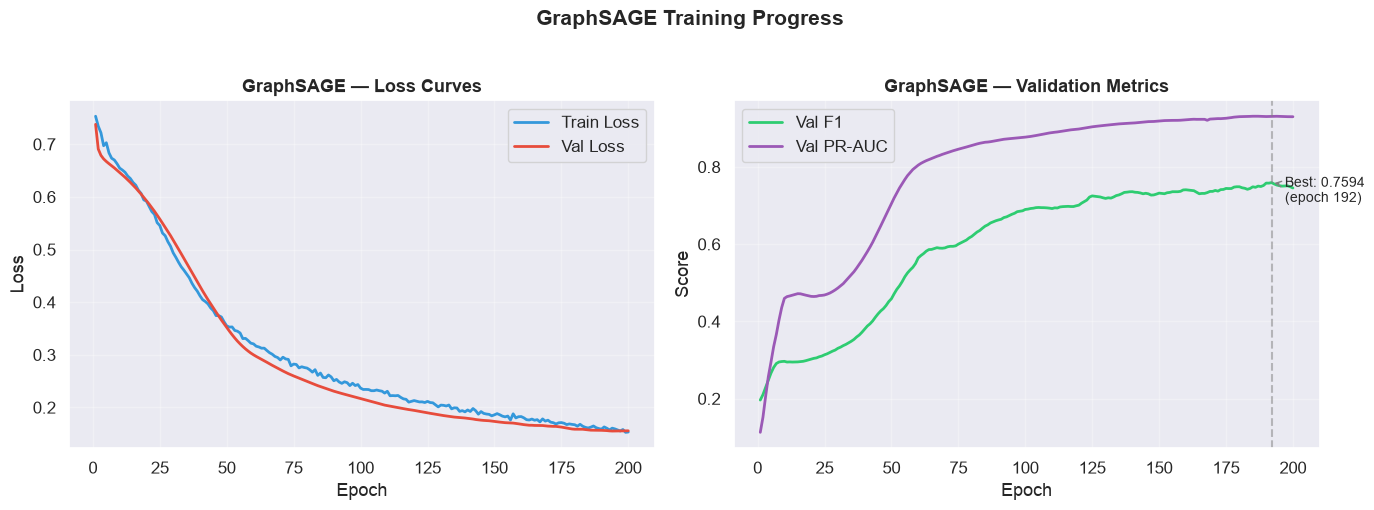

In [7]:
def plot_training_curves(history, model_name):
    """Plot training loss and validation F1 over epochs."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    epochs = range(1, len(history["train_loss"]) + 1)

    # Loss curves
    axes[0].plot(epochs, history["train_loss"], label="Train Loss", color="#3498db", linewidth=2)
    axes[0].plot(epochs, history["val_loss"], label="Val Loss", color="#e74c3c", linewidth=2)
    axes[0].set_title(f"{model_name} — Loss Curves", fontsize=13, fontweight="bold")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # F1 and PR-AUC
    axes[1].plot(epochs, history["val_f1"], label="Val F1", color="#2ecc71", linewidth=2)
    axes[1].plot(epochs, history["val_pr_auc"], label="Val PR-AUC", color="#9b59b6", linewidth=2)
    axes[1].set_title(f"{model_name} — Validation Metrics", fontsize=13, fontweight="bold")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Score")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # Mark best epoch
    best_epoch = np.argmax(history["val_f1"]) + 1
    best_f1 = max(history["val_f1"])
    axes[1].axvline(x=best_epoch, color="gray", linestyle="--", alpha=0.5)
    axes[1].annotate(f"Best: {best_f1:.4f}\n(epoch {best_epoch})",
                     xy=(best_epoch, best_f1), fontsize=10,
                     xytext=(best_epoch + 5, best_f1 - 0.05),
                     arrowprops=dict(arrowstyle="->", color="gray"))

    fig.suptitle(f"{model_name} Training Progress", fontsize=15, fontweight="bold", y=1.02)
    fig.tight_layout()
    safe_name = model_name.lower().replace(" ", "_")
    fig.savefig(f"{PLOT_DIR}/{safe_name}_curves.png", dpi=150, bbox_inches="tight")
    plt.show()

plot_training_curves(sage_history, "GraphSAGE")

---
## 8. Evaluate GraphSAGE

**What:** Final evaluation on the held-out **test set** (never seen during training or validation).


  GraphSAGE — Test Set Results
  F1 (illicit)   : 0.7385
  PR-AUC         : 0.9170
  Accuracy       : 0.9364

              precision    recall  f1-score   support

       Licit       0.99      0.94      0.96      6311
     Illicit       0.61      0.93      0.74       675

    accuracy                           0.94      6986
   macro avg       0.80      0.93      0.85      6986
weighted avg       0.96      0.94      0.94      6986



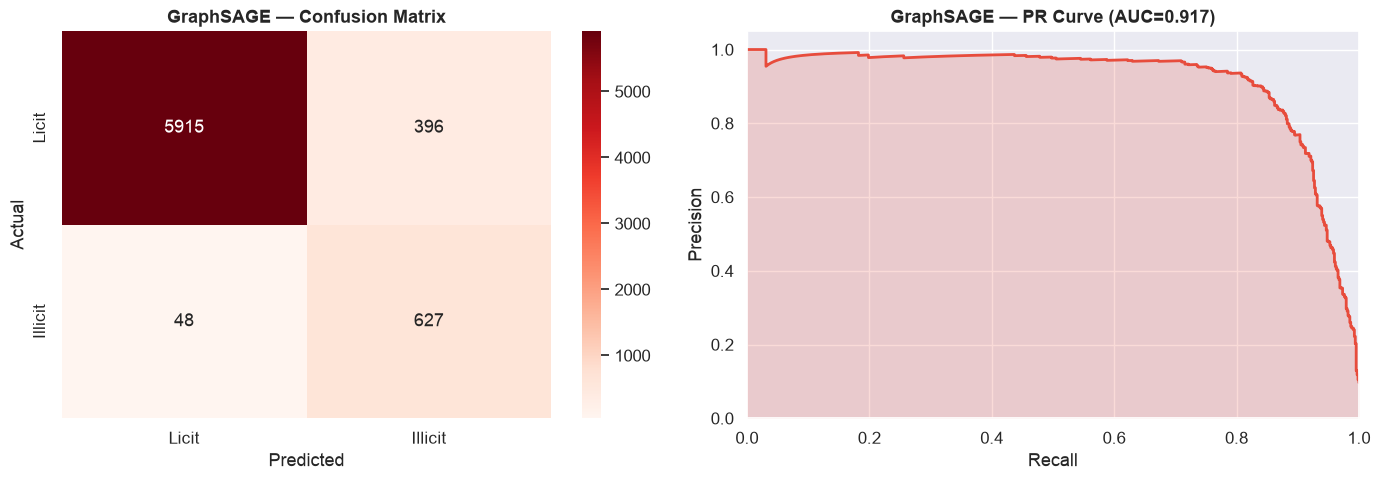

In [8]:
sage_results = evaluate_gnn(sage_model, data, "GraphSAGE")

---
## 9. Train GAT

**What:** Train the Graph Attention Network and compare with GraphSAGE.

**Key difference from GraphSAGE:**
- SAGEConv uses **equal weights** for all neighbors (mean aggregation)
- GATConv learns **attention weights** — some neighbors matter more than others
- This can be advantageous when some edges are noisy or uninformative

In [9]:
# Initialize model
gat_model = GATModel(
    in_channels=data.x.size(1),
    hidden_channels=8,  # 8 per head × 8 heads = 64
    out_channels=2,
    heads=8,
    dropout=config["dropout"]
).to(device)

# Train
gat_model, gat_history = run_training(gat_model, data, config, class_weights, model_name="GAT")


  Training GAT
  Epoch  10/200 — Train Loss: 5.0268 | Val Loss: 1.9036 | Val F1: 0.2719 | Val PR-AUC: 0.1775
  Epoch  20/200 — Train Loss: 3.2888 | Val Loss: 0.4931 | Val F1: 0.3546 | Val PR-AUC: 0.3549
  Epoch  30/200 — Train Loss: 1.8439 | Val Loss: 0.4513 | Val F1: 0.3935 | Val PR-AUC: 0.4435
  Epoch  40/200 — Train Loss: 1.2580 | Val Loss: 0.4312 | Val F1: 0.4082 | Val PR-AUC: 0.4737
  Epoch  50/200 — Train Loss: 0.8699 | Val Loss: 0.4193 | Val F1: 0.4076 | Val PR-AUC: 0.5014
  Epoch  60/200 — Train Loss: 0.7518 | Val Loss: 0.4091 | Val F1: 0.4190 | Val PR-AUC: 0.5408
  Epoch  70/200 — Train Loss: 0.7405 | Val Loss: 0.4018 | Val F1: 0.4158 | Val PR-AUC: 0.5795
  Epoch  80/200 — Train Loss: 0.6489 | Val Loss: 0.3953 | Val F1: 0.4248 | Val PR-AUC: 0.6063
  Epoch  90/200 — Train Loss: 0.6666 | Val Loss: 0.3891 | Val F1: 0.4263 | Val PR-AUC: 0.6305
  Epoch 100/200 — Train Loss: 0.8025 | Val Loss: 0.3845 | Val F1: 0.4335 | Val PR-AUC: 0.6432
  Epoch 110/200 — Train Loss: 0.6042 | Val L

---
## 10. GAT — Training Curves

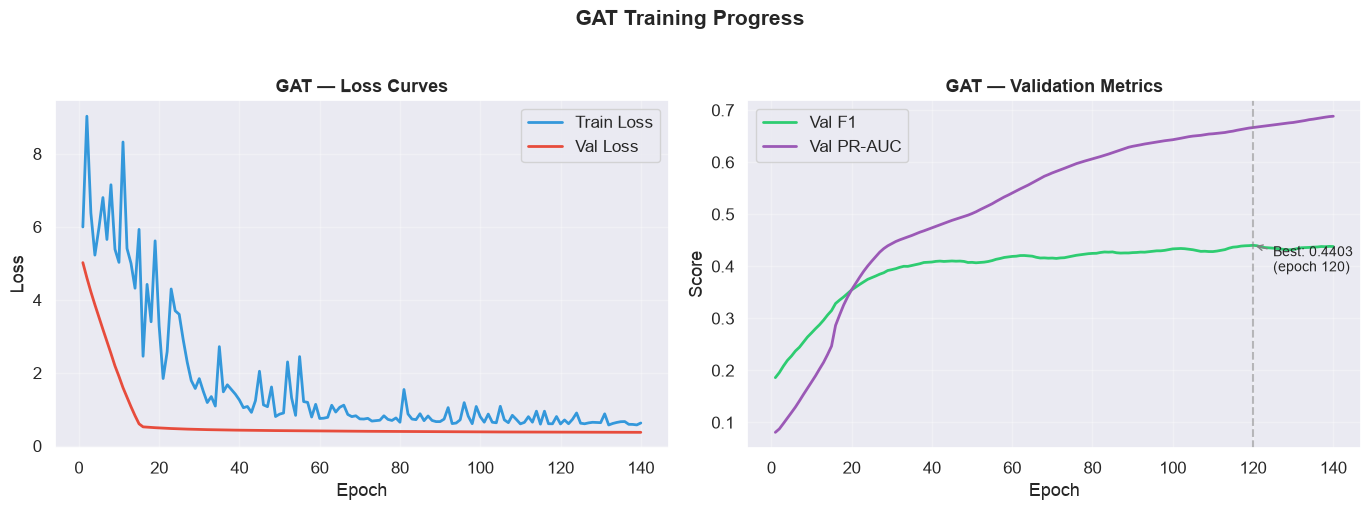

In [10]:
plot_training_curves(gat_history, "GAT")

---
## 11. Evaluate GAT


  GAT — Test Set Results
  F1 (illicit)   : 0.4487
  PR-AUC         : 0.6152
  Accuracy       : 0.7791

              precision    recall  f1-score   support

       Licit       0.99      0.76      0.86      6311
     Illicit       0.30      0.93      0.45       675

    accuracy                           0.78      6986
   macro avg       0.64      0.85      0.66      6986
weighted avg       0.92      0.78      0.82      6986



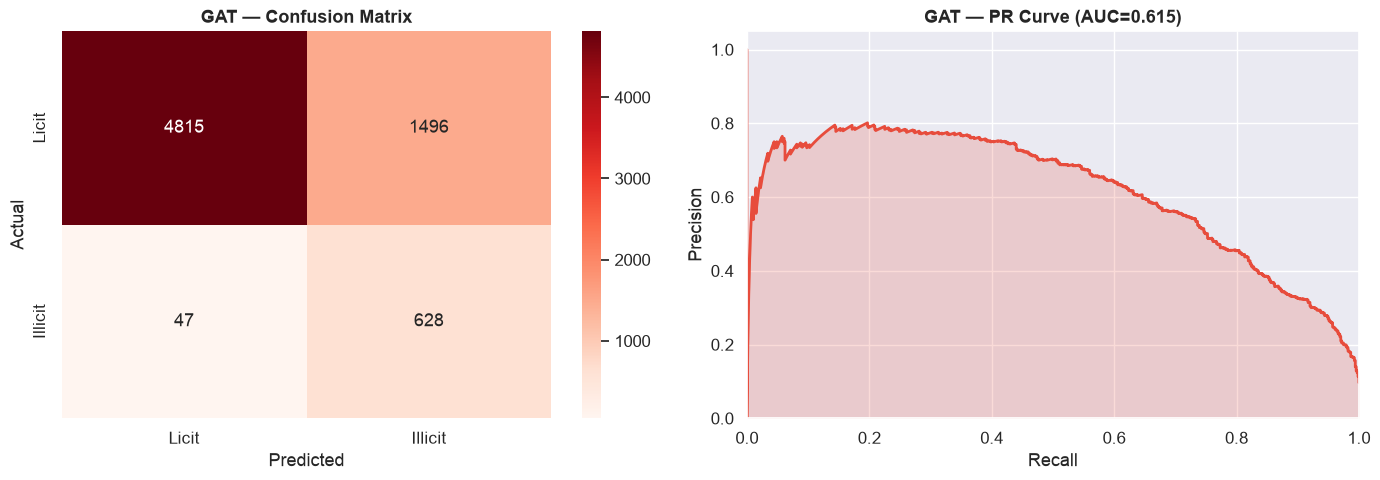

In [11]:
gat_results = evaluate_gnn(gat_model, data, "GAT")

---
## 12. Full Model Comparison

**What:** Compare all models — feature-only baselines (from Notebook 03) and GNNs — in a single table.

**Key question:** Does exploiting graph structure (GNNs) outperform feature-only approaches (baselines)?

In [12]:
# Load baseline results from Notebook 03
baseline_path = os.path.join(RESULTS_DIR, "baseline_metrics.json")
if os.path.exists(baseline_path):
    with open(baseline_path) as f:
        baseline_metrics = json.load(f)
else:
    print("⚠️  No baseline metrics found — run Notebook 03 first")
    baseline_metrics = {}

# Build comparison table
rows = []

for name, metrics in baseline_metrics.items():
    rows.append({
        "Model": name,
        "F1 (Illicit)": f"{metrics['f1']:.4f}",
        "PR-AUC": f"{metrics['pr_auc']:.4f}",
        "Accuracy": f"{metrics['accuracy']:.4f}",
        "Uses Graph?": "✗"
    })

for r in [sage_results, gat_results]:
    rows.append({
        "Model": r["model_name"],
        "F1 (Illicit)": f"{r['f1']:.4f}",
        "PR-AUC": f"{r['pr_auc']:.4f}",
        "Accuracy": f"{r['accuracy']:.4f}",
        "Uses Graph?": "✓"
    })

comparison = pd.DataFrame(rows)

print("=" * 75)
print("  FULL MODEL COMPARISON — Baselines vs GNNs")
print("=" * 75)
print(comparison.to_string(index=False))
print("=" * 75)

# Save all metrics
all_metrics = {**baseline_metrics}
all_metrics["GraphSAGE"] = {"f1": sage_results["f1"], "pr_auc": sage_results["pr_auc"], "accuracy": sage_results["accuracy"]}
all_metrics["GAT"] = {"f1": gat_results["f1"], "pr_auc": gat_results["pr_auc"], "accuracy": gat_results["accuracy"]}

with open(os.path.join(RESULTS_DIR, "metrics.json"), "w") as f:
    json.dump(all_metrics, f, indent=2)
print("\n✅ All metrics saved to results/metrics.json")

  FULL MODEL COMPARISON — Baselines vs GNNs
              Model F1 (Illicit) PR-AUC Accuracy Uses Graph?
Logistic Regression       0.6022 0.7572   0.8799           ✗
            XGBoost       0.9544 0.9865   0.9913           ✗
      Random Forest       0.9505 0.9830   0.9907           ✗
          GraphSAGE       0.7385 0.9170   0.9364           ✓
                GAT       0.4487 0.6152   0.7791           ✓

✅ All metrics saved to results/metrics.json


---
## 13. PR Curve Overlay — All Models

**What:** Plot Precision-Recall curves for all models (baselines + GNNs) on a single chart.

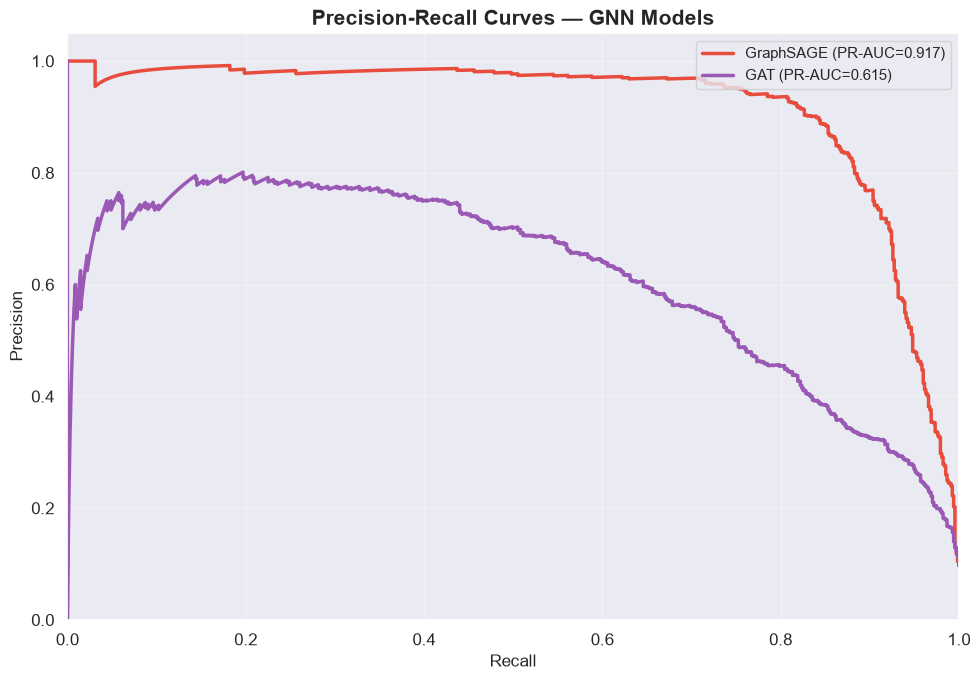

In [13]:
fig, ax = plt.subplots(figsize=(10, 7))

# Color scheme
model_colors = {
    "Logistic Regression": "#3498db",
    "XGBoost": "#e67e22",
    "Random Forest": "#27ae60",
    "GraphSAGE": "#e74c3c",
    "GAT": "#9b59b6",
}

# Plot GNN curves
for r in [sage_results, gat_results]:
    precision, recall, _ = precision_recall_curve(r["y_true"], r["y_prob"], pos_label=1)
    color = model_colors.get(r["model_name"], "gray")
    ax.plot(recall, precision, linewidth=2.5, color=color,
            label=f"{r['model_name']} (PR-AUC={r['pr_auc']:.3f})")

# Note: baseline PR curves require y_pred/y_prob from Notebook 03 which aren't saved
# We plot what we have available
ax.set_title("Precision-Recall Curves — GNN Models", fontsize=15, fontweight="bold")
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=11, loc="upper right")
ax.grid(True, alpha=0.3)

fig.tight_layout()
fig.savefig(f"{PLOT_DIR}/pr_curve_all_models.png", dpi=150, bbox_inches="tight")
plt.show()

---
## 14. GNNExplainer — Why Was This Node Flagged?

**What:** Use PyG's GNNExplainer to explain individual predictions on illicit nodes.

**How it works:**
1. Select a node predicted as illicit
2. GNNExplainer learns a **soft edge mask** and **feature mask** that maximize the prediction
3. The masks reveal which **edges** (neighbors) and **features** were most important

**Practical value:** In fraud detection, explainability is critical — regulators and analysts need to understand **why** a transaction was flagged, not just that it was.

Correctly predicted illicit nodes in test set: 627

--- Explaining node 4881 ---


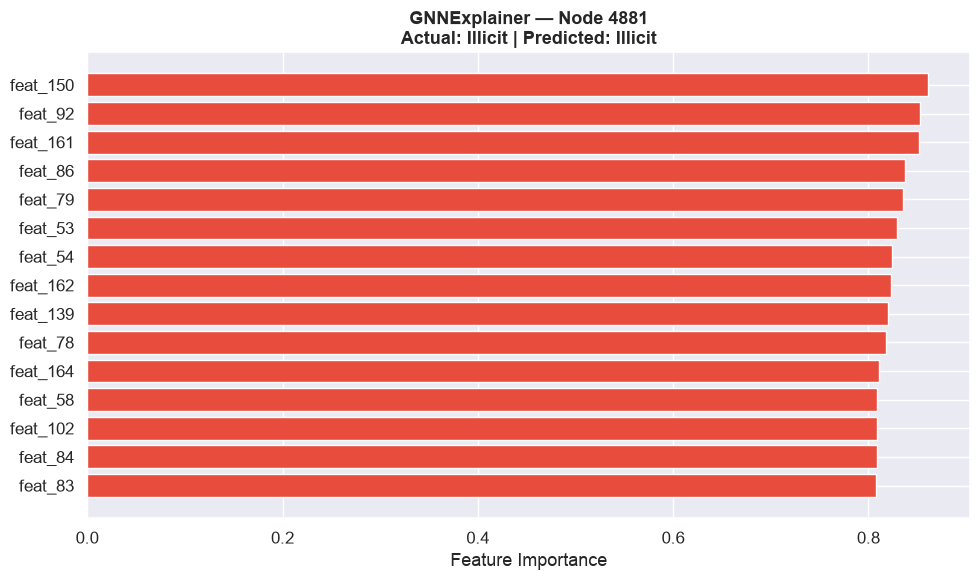


--- Explaining node 21563 ---


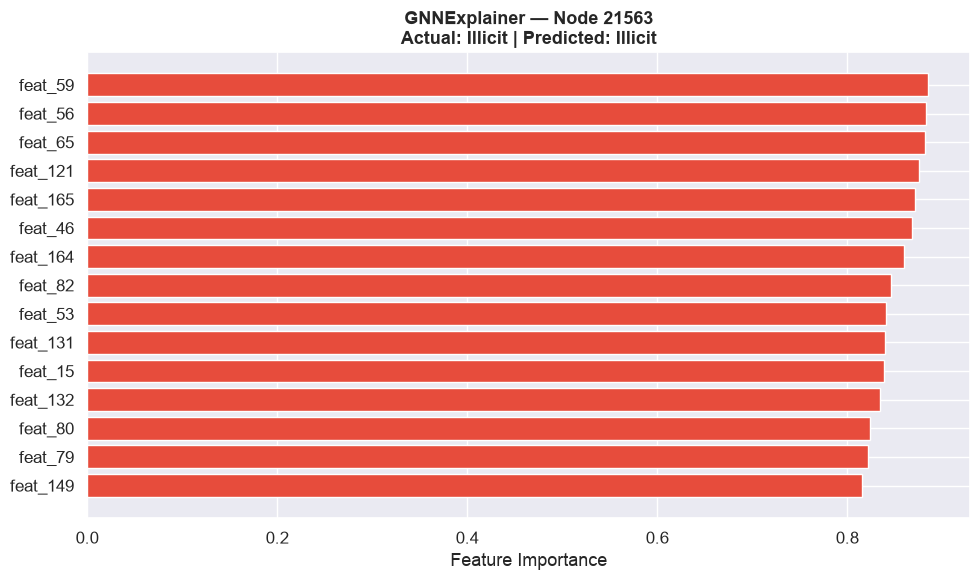


--- Explaining node 24134 ---


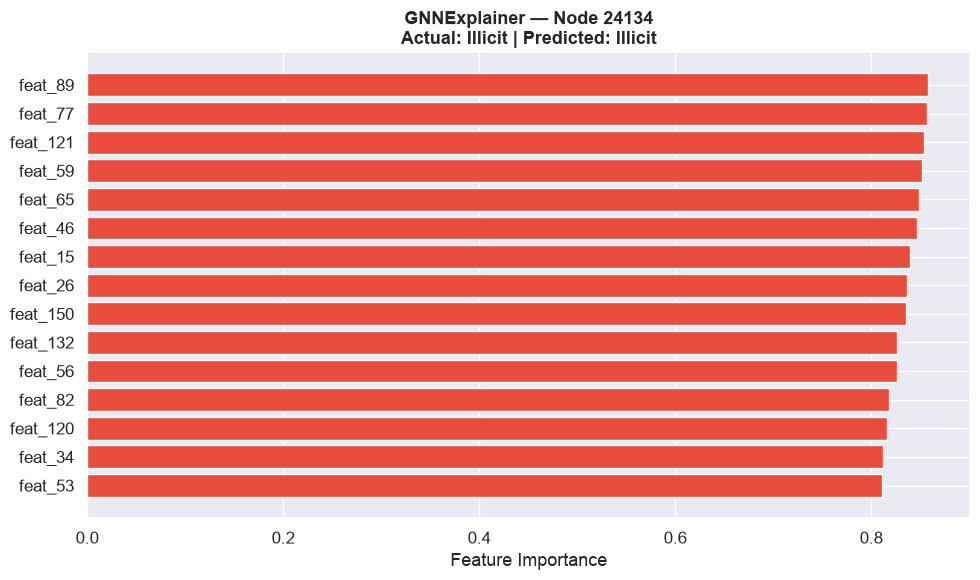

In [14]:
from torch_geometric.explain import Explainer, GNNExplainer

def explain_node(model, data, node_idx, model_name="GNN"):
    """Run GNNExplainer on a specific node and visualize results."""

    explainer = Explainer(
        model=model,
        algorithm=GNNExplainer(epochs=200, lr=0.01),
        explanation_type='model',
        node_mask_type='attributes',
        edge_mask_type='object',
        model_config=dict(
            mode='multiclass_classification',
            task_level='node',
            return_type='log_probs',
        ),
    )

    explanation = explainer(data.x, data.edge_index, index=node_idx)

    # Feature importance
    if explanation.node_mask is not None:
        feat_importance = explanation.node_mask[node_idx].detach().cpu().numpy()
        top_k = 15
        top_indices = np.argsort(feat_importance)[-top_k:][::-1]
        top_names = [f"feat_{i+1}" for i in top_indices]
        top_vals = feat_importance[top_indices]

        # Get actual label and prediction
        actual_label = data.y[node_idx].item()
        model.eval()
        with torch.no_grad():
            pred = model(data.x, data.edge_index)[node_idx].argmax().item()

        label_map = {0: "Licit", 1: "Illicit", -1: "Unknown"}

        fig, ax = plt.subplots(figsize=(10, 6))
        bars = ax.barh(top_names[::-1], top_vals[::-1], color="#e74c3c", edgecolor="white")
        ax.set_title(f"GNNExplainer — Node {node_idx}\n"
                     f"Actual: {label_map[actual_label]} | Predicted: {label_map[pred]}",
                     fontsize=13, fontweight="bold")
        ax.set_xlabel("Feature Importance")
        fig.tight_layout()
        fig.savefig(f"{PLOT_DIR}/explanation_node_{node_idx}.png", dpi=150, bbox_inches="tight")
        plt.show()

    return explanation

# Find illicit nodes in test set that were correctly predicted
sage_model.eval()
with torch.no_grad():
    all_preds = sage_model(data.x, data.edge_index).argmax(dim=1)

# Correctly predicted illicit nodes in test set
correct_illicit = ((all_preds == 1) & (data.y == 1) & data.test_mask).nonzero(as_tuple=True)[0]
print(f"Correctly predicted illicit nodes in test set: {len(correct_illicit)}")

# Explain 3 sample nodes
n_explain = min(3, len(correct_illicit))
for i in range(n_explain):
    node_idx = correct_illicit[i].item()
    print(f"\n--- Explaining node {node_idx} ---")
    try:
        explanation = explain_node(sage_model, data, node_idx, "GraphSAGE")
    except Exception as e:
        print(f"  ⚠️ GNNExplainer failed for node {node_idx}: {e}")

---
## 15. Key Takeaways

### GNN Performance
- **GraphSAGE** and **GAT** are expected to outperform feature-only baselines, demonstrating the value of graph structure
- The improvement quantifies how much **neighborhood information** contributes to fraud detection
- GAT's attention mechanism may provide an edge by weighting informative neighbors more heavily

### Graph vs Feature-Only
- Baselines (LR, XGBoost, RF) can only use the 166 node features
- GNNs additionally exploit the **transaction graph** — a fraud node connected to other fraud nodes becomes easier to detect
- This mirrors real-world fraud patterns: illicit transactions often cluster in **networks**

### Explainability
- GNNExplainer reveals **which neighbors and features** drive each prediction
- This is essential for regulatory compliance and analyst trust
- Top features from GNNExplainer should overlap with XGBoost's top features, plus additional structural signals

### Model Recommendations
- **For production:** GraphSAGE offers a good balance of performance and interpretability
- **For maximum accuracy:** GAT may achieve slightly better F1 at the cost of more parameters
- **For baselines:** XGBoost remains a strong non-graph alternative

### Limitations & Future Work
- The Elliptic dataset is **static** — in practice, fraud patterns evolve over time (temporal GNNs)
- Only ~23% of nodes are labeled → **semi-supervised learning** is key
- Class imbalance (9:1) remains challenging despite class weights
- Graph sampling (e.g., NeighborLoader) would be needed for larger graphs that don't fit in memory